# CrisisLexT26

Domain Adaptation with Adversarial Training and Graph Embeddings

---

## A. Original description

There are three files per crisis, for each of the following disasters:
- 2012_Colorado_wildfires
- 2012_Costa_Rica_earthquake
- 2012_Guatemala_earthquake
- 2012_Italy_earthquakes
- 2012_Philipinnes_floods
- 2012_Typhoon_Pablo
- 2012_Venezuela_refinery
- 2013_Alberta_floods
- 2013_Australia_bushfire
- 2013_Bohol_earthquake
- 2013_Boston_bombings
- 2013_Brazil_nightclub_fire
- 2013_Colorado_floods
- 2013_Glasgow_helicopter_crash
- 2013_LA_airport_shootings
- 2013_Lac_Megantic_train_crash
- 2013_Manila_floods
- 2013_NY_train_crash
- 2013_Queensland_floods
- 2013_Russia_meteor
- 2013_Sardinia_floods
- 2013_Savar_building_collapse
- 2013_Singapore_haze
- 2013_Spain_train_crash
- 2013_Typhoon_Yolanda
- 2013_West_Texas_explosion


Each directory contains tweets posted during event, organized in two comma-separated values (.csv) files containing tweet-ids for all the tweets filtered for this event, plus the text of the tweets and labels only for the labeled ones. The directory also contains a file with details about the event.

#### Event description file `*-event_description.json`

**Contents:** This file contains location and temporal details about the event, along with a brief categorization, collection size, and the list of keywords used for filtering.

**Data Format:** JSON (check file)

**Top-level fields:** name, time, location, categorization, keywords, size

#### Labeled tweets file `*-tweets_labeled.csv`

**Contents:** This file contains slightly above 1000 tweets labeled by crowdsourcing workers according to *informativeness* (as informative, or not informative), *information type*, and *source*. Each tweet is accompanied by three labels, each being the result of the majority voting among at least 3 crowdsourcing workers.

**Data Format:** One tweet per line with the following comma-separated fields:
*Tweet ID, Tweet Text, Information Source, Information Type, Informativeness*

**Labels:**
The file contains labels provided by crowdsource workers, indicating if the tweet is:

 - *Informativeness:* Related and informative, Related - but not informative, Not related, Not applicable
 - *Information source:* Eyewitness, Government, NGOs, Business, Media, Outsiders, Not applicable
 - *Information type:* Affected individuals, Infrastructure and utilities, Donations and volunteering, Caution and advice, Sympathy and support, Other Useful Information, Not applicable

A description of the labeling process can be found in the reference below.

#### Tweet ids file `*-tweetids_entire_period`

**Contents:** This file contains a list of tweet-ids for all the tweets filtered for this event.

**Data Format:** One tweet per line with the following comma-separated fields:
  *Timestamp, Tweet-ID, Included*

**"Included" field:**
The "Included" file indicates if the tweet was included in the period we analyzed (Y) or not (N). The inclusion/exclusion rule is based on frequency over time as detailed in the reference below.

### Reference

[Olteanu et al. 2015] A. Olteanu, S. Vieweg, C. Castillo. 2015. What to Expect When the Unexpected Happens: Social Media Communications Across Crises. In Proceedings of the ACM 2015 Conference on Computer Supported Cooperative Work and Social Computing (CSCW '15). ACM, Vancouver, BC, Canada.

### Questions/inquiries

For inquiries please contact [Alexandra Olteanu](mailto:alexandra.olteanu@epfl.ch), or Sarah Vieweg, or Carlos Castillo.
 

## B. Overview

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisLexT26' / 'CrisisLexT26'

Loading the `2012_Colorado_wildfires.csv` file

In [2]:
filepath = dataset_path / '2012_Colorado_wildfires' / '2012_Colorado_wildfires-tweets_labeled.csv'

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df = pd.read_csv(filepath)
df.columns = df.columns.str.strip()

In [3]:
df.head()

,Tweet ID,Tweet Text,Information Source,Information Type,Informativeness
0,211040709124440064,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,Not labeled,Not labeled,Not related
1,211111710294163457,RT @Jack4Ward: Get in on the fun every Thursda...,Not labeled,Not labeled,Not related
2,211157222699433985,Welcome to our newest STUDENTathlete- Reagan B...,Not labeled,Not labeled,Not related
3,211162553659830272,Denver Post: #Colorado governor signs bill cre...,Not labeled,Not labeled,Not related
4,211216962162933761,Pretty sure I'm going to live in Manitou Sprin...,Not labeled,Not labeled,Not related


In [4]:
csv_array = df.values

print(f'Loaded {len(df)} rows from: {filepath}')
print(csv_array[:5])

Loaded 1200 rows from: /Users/nhut/Library/CloudStorage/GoogleDrive-nduo221@aucklanduni.ac.nz/Shared drives/Nhut - Disaster on Social Media - COMPSCI 792 Research Project/Datasets/CrisisLexT26/CrisisLexT26/2012_Colorado_wildfires/2012_Colorado_wildfires-tweets_labeled.csv
[[211040709124440064
  '#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #Florida #Colorado #Iowa #Nevada #Virginia #NV #mlb Travel Destinations---&gt;http://t.co/TIHBJKF2'
  'Not labeled' 'Not labeled' 'Not related']
 [211111710294163457
  'RT @Jack4Ward: Get in on the fun every Thursday with the @csindependent #FunBrief http://ow.ly/br9Wi #CoSprings #Colorado'
  'Not labeled' 'Not labeled' 'Not related']
 [211157222699433985
  'Welcome to our newest STUDENTathlete- Reagan Biechler\xa0from Colorado Springs (CO) ’13- Baseball. http://t.co/lzeiYMpq'
  'Not labeled' 'Not labeled' 'Not related']
 [211162553659830272
  'Denver Post: #Colorado governor signs bill creating rules for public access to ballots http://t.co/Hmp1wQ8P

## C. Preprocess

Combine all train, dev, test files from both events to one

In [5]:
df[df["Informativeness"]=='Not applicable'].head()

,Tweet ID,Tweet Text,Information Source,Information Type,Informativeness
7,211281973870727170,#colorado. Told you its #amazing http://t.co/6...,Not labeled,Not labeled,Not applicable
179,213278894600634369,Forlan no Inter: sites na europa dizem que sim...,Not labeled,Not labeled,Not applicable
374,216741229650649088,RT @jeffestes: #weberfire http://t.co/2pZqhWAS...,Not labeled,Not labeled,Not applicable
404,217018900959858688,Ouvir a torcida do meu #Inter cantando na Ilha...,Not labeled,Not labeled,Not applicable
787,218102289687261184,"Colorado Springs, 2e plus grande ville du Colo...",Not labeled,Not labeled,Not applicable


In [6]:
files = [
    {
        "filename": "2012_Colorado_wildfires/2012_Colorado_wildfires-tweets_labeled.csv",
        "country": "US",
        "event_type": "wildfire",
        "event_name": "2012 Colorado Wildfires",
        "year": 2012,
    },
    {
        "filename": "2012_Costa_Rica_earthquake/2012_Costa_Rica_earthquake-tweets_labeled.csv",
        "country": "Costa Rica",
        "event_type": "earthquake",
        "event_name": "2012 Costa Rica Earthquake",
        "year": 2012,
    },
    {
        "filename": "2012_Guatemala_earthquake/2012_Guatemala_earthquake-tweets_labeled.csv",
        "country": "Guatemala",
        "event_type": "earthquake",
        "event_name": "2012 Guatemala Earthquake",
        "year": 2012,
    },
    {
        "filename": "2012_Italy_earthquakes/2012_Italy_earthquakes-tweets_labeled.csv",
        "country": "Italy",
        "event_type": "earthquake",
        "event_name": "2012 Italy Earthquakes",
        "year": 2012,
    },
    {
        "filename": "2012_Philipinnes_floods/2012_Philipinnes_floods-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "flood",
        "event_name": "2012 Philippines Floods",
        "year": 2012,
    },
    {
        "filename": "2012_Typhoon_Pablo/2012_Typhoon_Pablo-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "storm",
        "event_name": "2012 Typhoon Pablo",
        "year": 2012,
    },
    {
        "filename": "2013_Alberta_floods/2013_Alberta_floods-tweets_labeled.csv",
        "country": "Canada",
        "event_type": "flood",
        "event_name": "2013 Alberta Floods",
        "year": 2013,
    },
    {
        "filename": "2013_Australia_bushfire/2013_Australia_bushfire-tweets_labeled.csv",
        "country": "Australia",
        "event_type": "wildfire",
        "event_name": "2013 Australia Bushfire",
        "year": 2013,
    },
    {
        "filename": "2013_Bohol_earthquake/2013_Bohol_earthquake-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "earthquake",
        "event_name": "2013 Bohol Earthquake",
        "year": 2013,
    },
    {
        "filename": "2013_Colorado_floods/2013_Colorado_floods-tweets_labeled.csv",
        "country": "US",
        "event_type": "flood",
        "event_name": "2013 Colorado Floods",
        "year": 2013,
    },
    {
        "filename": "2013_Manila_floods/2013_Manila_floods-tweets_labeled.csv",
        "country": "Philippines",
        "event_type": "flood",
        "event_name": "2013 Manila Floods",
        "year": 2013,
    },
    {
        "filename": "2013_Queensland_floods/2013_Queensland_floods-tweets_labeled.csv",
        "country": "Australia",
        "event_type": "flood",
        "event_name": "2013 Queensland Floods",
        "year": 2013,
    },
    {
        "filename": "2013_Russia_meteor/2013_Russia_meteor-tweets_labeled.csv",
        "country": "US",
        "event_type": "meteor",
        "event_name": "2013 Russia Meteor",
        "year": 2013,
    },
    {
        "filename": "2013_Sardinia_floods/2013_Sardinia_floods-tweets_labeled.csv",
        "country": "US",
        "event_type": "flood",
        "event_name": "2013 Sardinia Floods",
        "year": 2013,
    },
    {
        "filename": "2013_Typhoon_Yolanda/2013_Typhoon_Yolanda-tweets_labeled.csv",
        "country": "US",
        "event_type": "storm",
        "event_name": "2013 Typhoon Yolanda",
        "year": 2013,
    },
    # Do not include following events
    # {
    #     "filename": "2013_Singapore_haze/2013_Singapore_haze-tweets_labeled.csv",
    # },
    # They are not natural disasters
    # {
    #     "filename": "2012_Venezuela_refinery/2012_Venezuela_refinery-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Glasgow_helicopter_crash/2013_Glasgow_helicopter_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_LA_airport_shootings/2013_LA_airport_shootings-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Lac_Megantic_train_crash/2013_Lac_Megantic_train_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_NY_train_crash/2013_NY_train_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Savar_building_collapse/2013_Savar_building_collapse-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Spain_train_crash/2013_Spain_train_crash-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Boston_bombings/2013_Boston_bombings-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_Brazil_nightclub_fire/2013_Brazil_nightclub_fire-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
    # {
    #     "filename": "2013_West_Texas_explosion/2013_West_Texas_explosion-tweets_labeled.csv",
    #     "event_type": "artificial_incident",
    # },
]

In [7]:

df_list = []

for file in files:
    filename = file["filename"]
    filepath = dataset_path / filename
    if not filepath.exists():
        print(f"Not found: {filepath}")
        continue

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    # remove `'Not applicable'` in `Informativeness` column
    df = df[df["Informativeness"] != "Not applicable"]

    
    df["event_type"] = file["event_type"]
    df['event_name'] = file['event_name']
    df["country"] = file["country"]
    df["year"] = file["year"]

    # *Informativeness:* Related and informative, Related - but not informative, Not related, Not applicable
    df["relevant"] = df["Informativeness"].apply(lambda x: False if x == "Not related" else True)
    df['dataset'] = 'CrisisLexT26'
    # Store other metadata as JSON text in `meta`.
    df["meta"] = df.apply(
        lambda row: {
            "file_name": filename,
            "Information Source": row["Information Source"],
            "Information Type": row["Information Type"],
            "Informativeness": row["Informativeness"],
        },
        axis=1,
    )
    df_list.append(df)

# ignore_index=True creates clean, sequential row numbers
merged_df = pd.concat(df_list, ignore_index=True)
merged_df.rename(columns={"Tweet ID": "tweet_id"}, inplace=True)
merged_df.rename(columns={"Tweet Text": "tweet_text"}, inplace=True)
merged_df.rename(columns={'Informativeness': 'original_relevant_label'}, inplace=True)
merged_df['relevant'] = merged_df['original_relevant_label'].apply(
    lambda x: False if x in ['Not applicable', 'Not related'] else True)
merged_df['original_humanitarian_label'] = merged_df['Information Type']
merged_df['humanitarian_label'] = np.nan
drop_cols = ["Information Source", "Information Type"]
merged_df.drop(columns=drop_cols, inplace=True)
merged_df = merged_df[dataset_settings.dataset_extended_cols]
merged_df.head()

,tweet_id,tweet_text,relevant,humanitarian_label,event_name,event_type,dataset,original_relevant_label,original_humanitarian_label,year,meta
0,211040709124440064,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,False,NaN,2012 Colorado Wildfires,wildfire,CrisisLexT26,Not related,Not labeled,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
1,211111710294163457,RT @Jack4Ward: Get in on the fun every Thursda...,False,NaN,2012 Colorado Wildfires,wildfire,CrisisLexT26,Not related,Not labeled,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
2,211157222699433985,Welcome to our newest STUDENTathlete- Reagan B...,False,NaN,2012 Colorado Wildfires,wildfire,CrisisLexT26,Not related,Not labeled,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
3,211162553659830272,Denver Post: #Colorado governor signs bill cre...,False,NaN,2012 Colorado Wildfires,wildfire,CrisisLexT26,Not related,Not labeled,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...
4,211216962162933761,Pretty sure I'm going to live in Manitou Sprin...,False,NaN,2012 Colorado Wildfires,wildfire,CrisisLexT26,Not related,Not labeled,2012,{'file_name': '2012_Colorado_wildfires/2012_Co...


In [8]:
merged_df[['original_relevant_label']].value_counts()

original_relevant_label      
Related and informative          10223
Related - but not informative     3997
Not related                       2026
Name: count, dtype: int64

In [9]:
merged_df[['original_humanitarian_label']].value_counts()

original_humanitarian_label 
Other Useful Information        3913
Sympathy and support            2542
Not labeled                     2021
Affected individuals            2019
Donations and volunteering      1986
Caution and advice              1974
Infrastructure and utilities    1107
Not applicable                   684
Name: count, dtype: int64

In [10]:
merged_df[['original_humanitarian_label', 'original_relevant_label']].value_counts()

original_humanitarian_label   original_relevant_label      
Other Useful Information      Related and informative          2974
Sympathy and support          Related - but not informative    2086
Not labeled                   Not related                      2021
Affected individuals          Related and informative          1897
Caution and advice            Related and informative          1890
Donations and volunteering    Related and informative          1780
Infrastructure and utilities  Related and informative          1017
Other Useful Information      Related - but not informative     938
Not applicable                Related - but not informative     474
Sympathy and support          Related and informative           456
Not applicable                Related and informative           209
Donations and volunteering    Related - but not informative     206
Affected individuals          Related - but not informative     122
Infrastructure and utilities  Related - but not informat

In [11]:
merged_df[['original_relevant_label', 'original_humanitarian_label']].groupby(['original_relevant_label']).value_counts()

original_relevant_label        original_humanitarian_label 
Not related                    Not labeled                     2021
                               Infrastructure and utilities       3
                               Not applicable                     1
                               Other Useful Information           1
Related - but not informative  Sympathy and support            2086
                               Other Useful Information         938
                               Not applicable                   474
                               Donations and volunteering       206
                               Affected individuals             122
                               Infrastructure and utilities      87
                               Caution and advice                84
Related and informative        Other Useful Information        2974
                               Affected individuals            1897
                               Caution and advice       

In [12]:
merged_df.loc[
    (merged_df['original_relevant_label'] == 'Related and informative') &
    (merged_df['original_humanitarian_label'] == 'Not applicable')
]['tweet_text'].values

array(['Due to Colorado wildfires, the trip is cancelled. So instead we will be driving through Nevada, and going to California.',
       'Wed Night:Wednesday Night Mostly cloudy,Low around 66.Southwest wind 5 to 7 mph be safe &amp; smart #Utah #4thOfJuly #fireworks #Wildfire',
       'costa rica earthquake 7,9SR', 'http://t.co/9knIr8Ie #temblorcr',
       'RT @felipezarate: Playa Ostional Guanacaste, luego del #TemblorCR de 7.6, 05/09/2012 Fuente: http://t.co/X69XeHQV http://t.co/FulLKgCC',
       'Para los que no han visto el vídeo de Amelia Rueda en el #temblorCR http://t.co/jEp3i7ne',
       'Hubo terremoto en Costa Rica .! O:',
       'RT @LAFD: #LAquake #Earthquake Emergency Mode discontinued. No significant damage, injury or loss of life. LAFD in normal… http://t.co ...',
       '#Sismo #Earthquake 4.5 en #Jujuy -Epicentro 162km NNO de San Salvador de Jujuy http://t.co/crNgM4CM',
       'RT @correoorinoco: Sismo de magnitud 4,3 se registró en costa norte de #Peru http://t.co/odQ

In [13]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {merged_df['tweet_text'].duplicated().sum()}")

# # Remove duplicates
merged_df = merged_df.drop_duplicates(subset=['tweet_text'])

merged_df['tweet_text'].value_counts()

Number of duplicate tweets: 1325


tweet_text
#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #Florida #Colorado #Iowa #Nevada #Virginia #NV #mlb Travel Destinations---&gt;http://t.co/TIHBJKF2    1
In times like this, people should know how to follow protocol for rescue purposes. @rapplerdotcom #MaringPH                                        1
RT @PhilstarNews: PRIVATE SECTOR work suspension is at the discretion of companies. Call your HR for info. | #maringupdates http://t.co/WO7…       1
Kahit 2 hours lang tulog ko, hindi na ko matutulog. Baka kasi mamaya, nasa 1st floor na yung baha. Tama na Bagyong #MaringPH :(                    1
RT @rapplerdotcom: Tweet us #MaringPH photos using #FloodPH and follow updates on this LIVE BLOG: http://t.co/GZm9op3MFS http://t.co/16EEO9…       1
                                                                                                                                                  ..
RT @theprettyEJ: PLS HELP RT #Rescueph #ReliefPH at Gemini St. Villariva Subd. Sto.Domingo Cain

In [14]:
import csv
# Use QUOTE_ALL to quote all fields, ensuring newlines and special characters are properly handled
merged_df.to_csv('../data/datasets/CrisisLexT26.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifying

In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14921 entries, 0 to 16245
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tweet_id                     14921 non-null  int64  
 1   tweet_text                   14921 non-null  object 
 2   relevant                     14921 non-null  bool   
 3   humanitarian_label           0 non-null      float64
 4   event_name                   14921 non-null  object 
 5   event_type                   14921 non-null  object 
 6   dataset                      14921 non-null  object 
 7   original_relevant_label      14921 non-null  object 
 8   original_humanitarian_label  14921 non-null  object 
 9   year                         14921 non-null  int64  
 10  meta                         14921 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 1.3+ MB


In [16]:
merged_df.describe(include='all')

,tweet_id,tweet_text,relevant,humanitarian_label,event_name,event_type,dataset,original_relevant_label,original_humanitarian_label,year,meta
count,1.492100e+04,14921,14921,0.0,14921,14921,14921,14921,14921,14921.000000,14921
unique,NaN,14921,2,NaN,15,5,1,3,8,NaN,926
top,NaN,#Intern #US #TATTOO #Wisconsin #Ohio #NC #PA #...,True,NaN,2013 Russia Meteor,flood,CrisisLexT26,Related and informative,Other Useful Information,NaN,{'file_name': '2012_Costa_Rica_earthquake/2012...
freq,NaN,1,13020,NaN,1223,5708,14921,9372,3570,NaN,387
mean,3.125926e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.598083,NaN
std,6.890050e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.490302,NaN
min,2.034409e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
25%,2.439539e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
50%,3.024034e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
75%,3.892585e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN


<Axes: xlabel='relevant'>

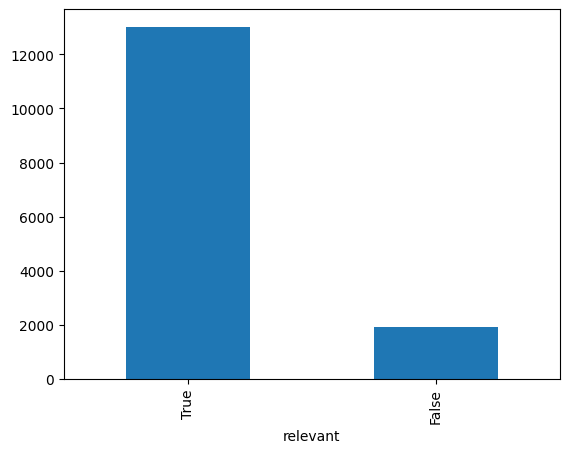

In [17]:
merged_df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

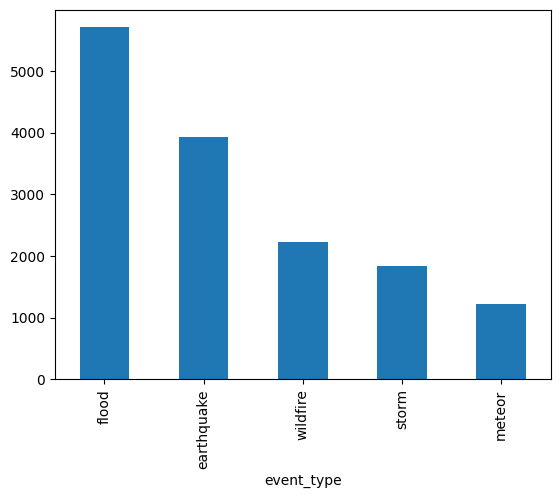

In [18]:
merged_df['event_type'].value_counts().plot(kind='bar')